In [8]:
# Encode the Type column (L=0, M=1, H=2)
df['Type_encoded'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})
df_clean = df.drop(columns=['Type'])
df_clean.to_csv('../data/processed/ai4i_clean.csv', index=False)
print(f"Saved: {df_clean.shape}")

Saved: (10000, 12)


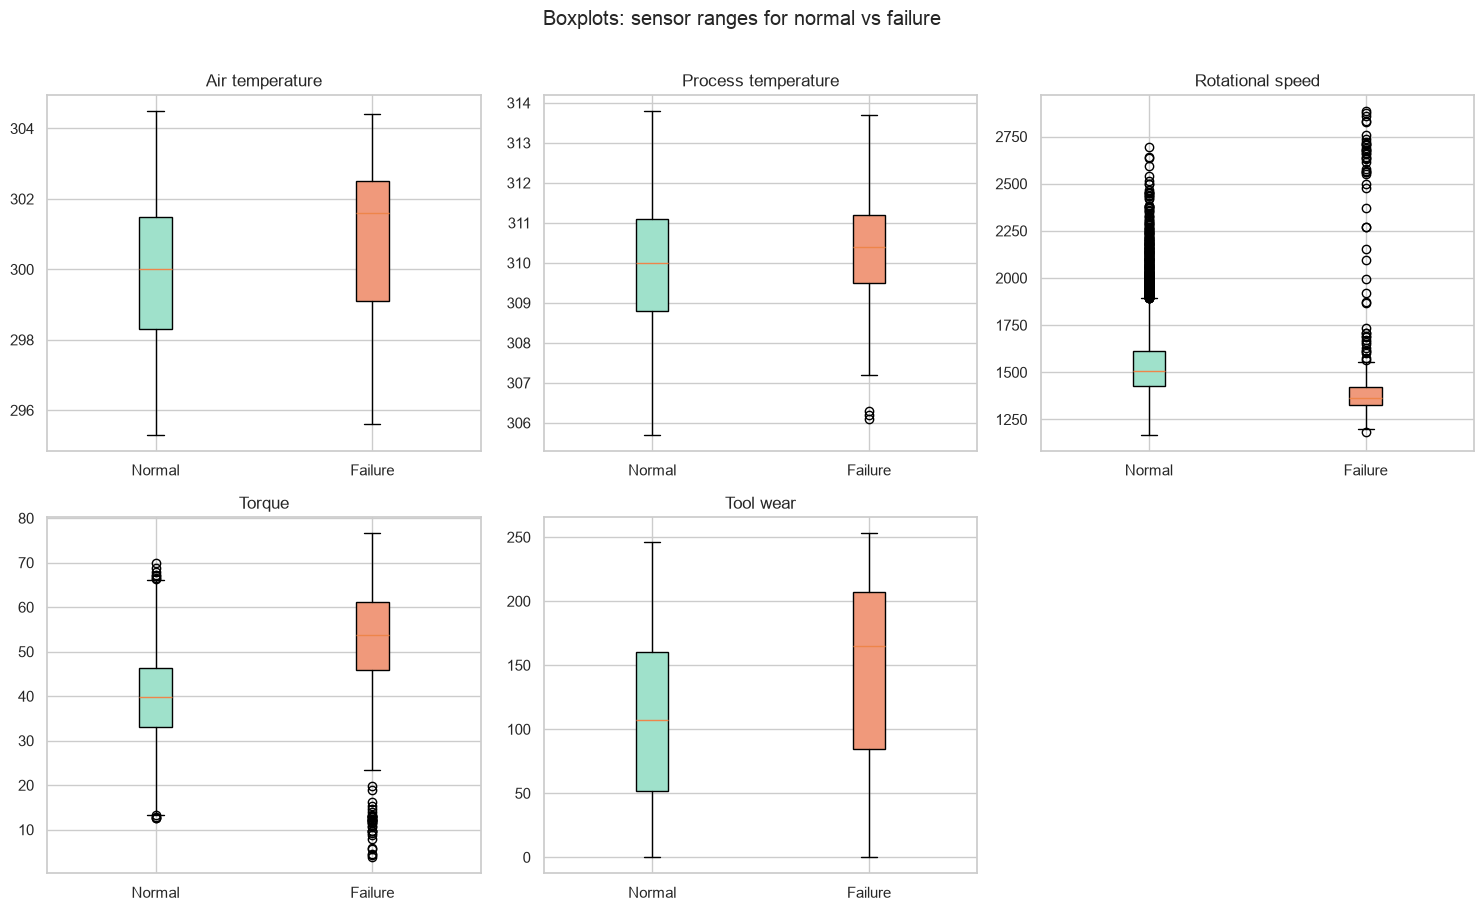

In [5]:
sensor_cols = ['Air temperature', 'Process temperature',
               'Rotational speed', 'Torque', 'Tool wear']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    data_to_plot = [
        df.loc[df['Machine failure'] == 0, col].dropna(),
        df.loc[df['Machine failure'] == 1, col].dropna()
    ]

    bp = axes[i].boxplot(
        data_to_plot,
        patch_artist=True,
        tick_labels=['Normal', 'Failure']   # changed from labels=...
    )

    bp['boxes'][0].set_facecolor('#9FE1CB')
    bp['boxes'][1].set_facecolor('#F0997B')
    axes[i].set_title(col)

axes[5].axis('off')
plt.suptitle('Boxplots: sensor ranges for normal vs failure', y=1.01)
plt.tight_layout()
plt.savefig('../docs/boxplots.png', dpi=150)
plt.show()

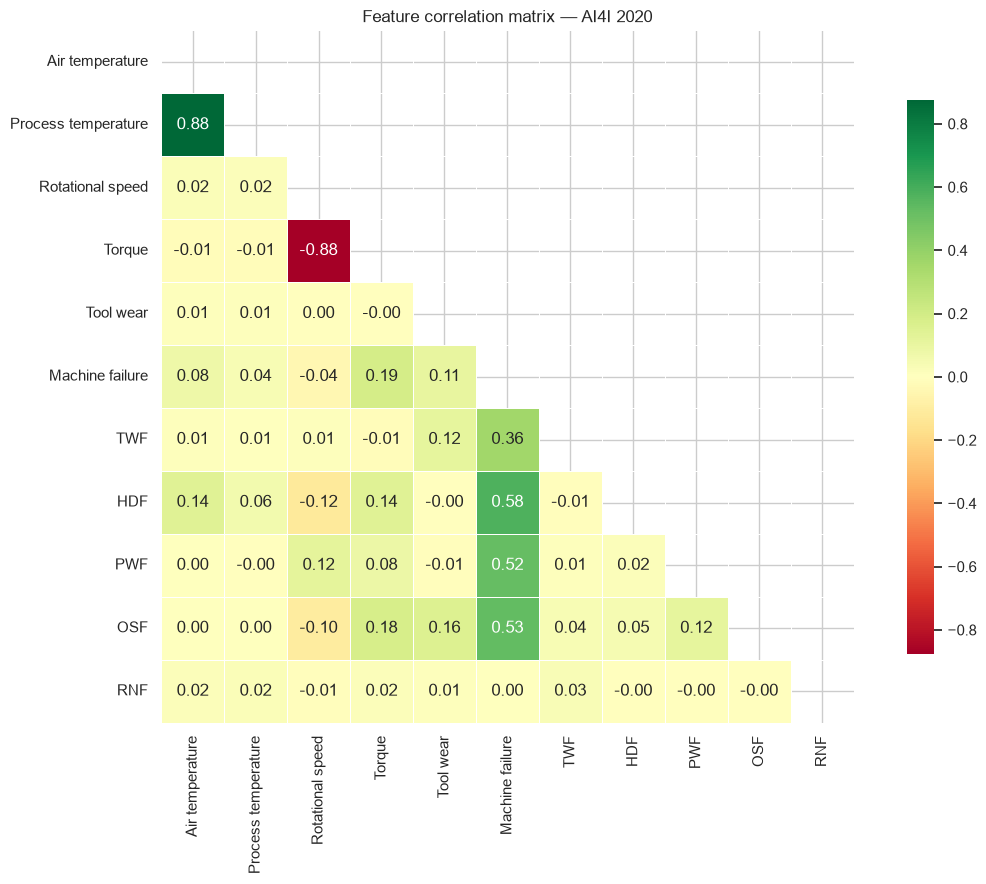

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature correlation matrix — AI4I 2020')
plt.tight_layout()
plt.savefig('../docs/correlation_heatmap.png', dpi=150)
plt.show()

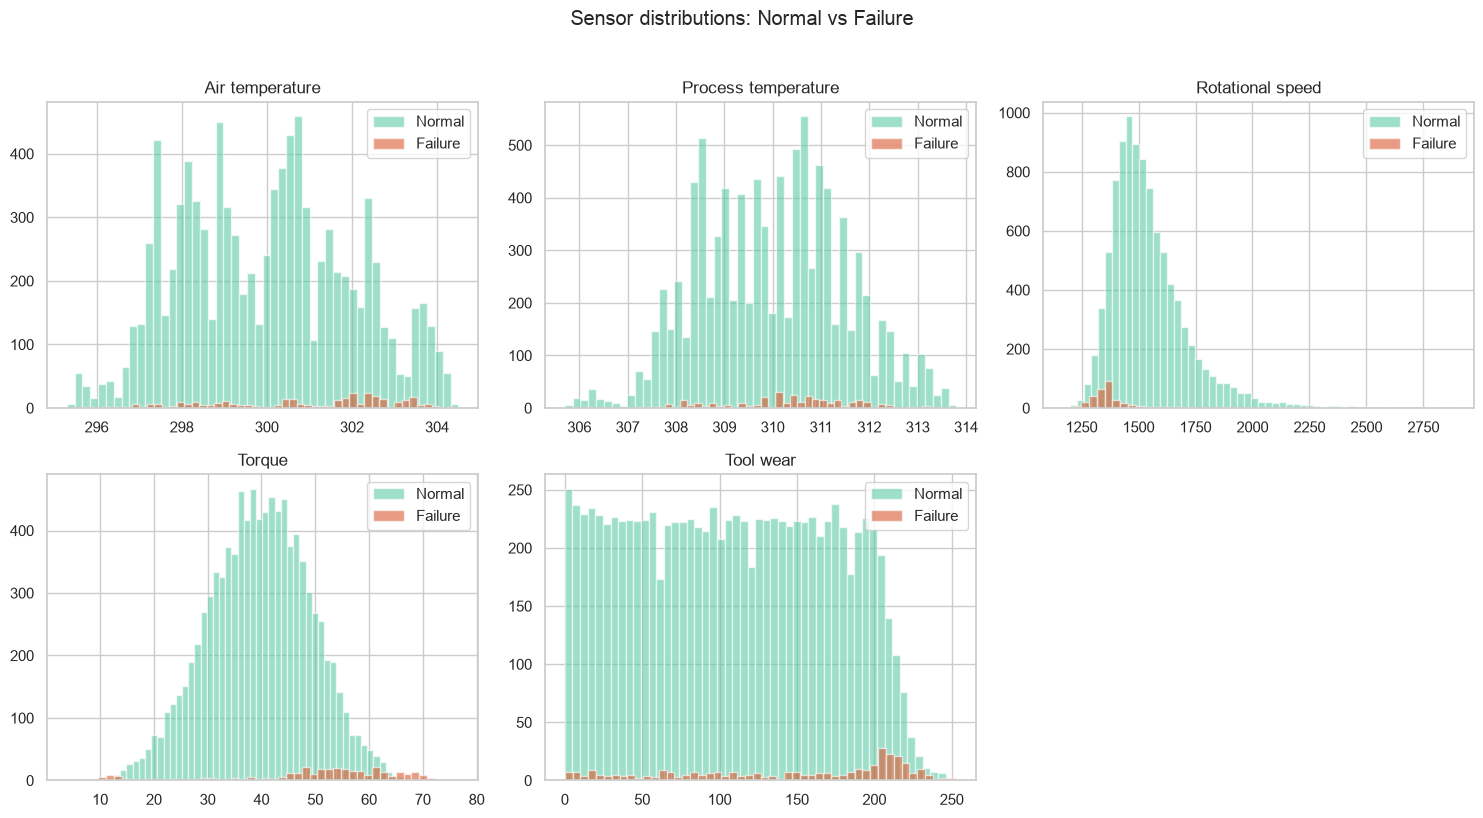

In [10]:
sensor_cols = ['Air temperature', 'Process temperature',
               'Rotational speed', 'Torque', 'Tool wear']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(df[df['Machine failure'] == 0][col], bins=50,
                 alpha=0.6, label='Normal', color='#5DCAA5')
    axes[i].hist(df[df['Machine failure'] == 1][col], bins=50,
                 alpha=0.6, label='Failure', color='#D85A30')
    axes[i].set_title(col)
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Sensor distributions: Normal vs Failure', y=1.02)
plt.tight_layout()
plt.savefig('../docs/sensor_distributions.png', dpi=150)
plt.show()

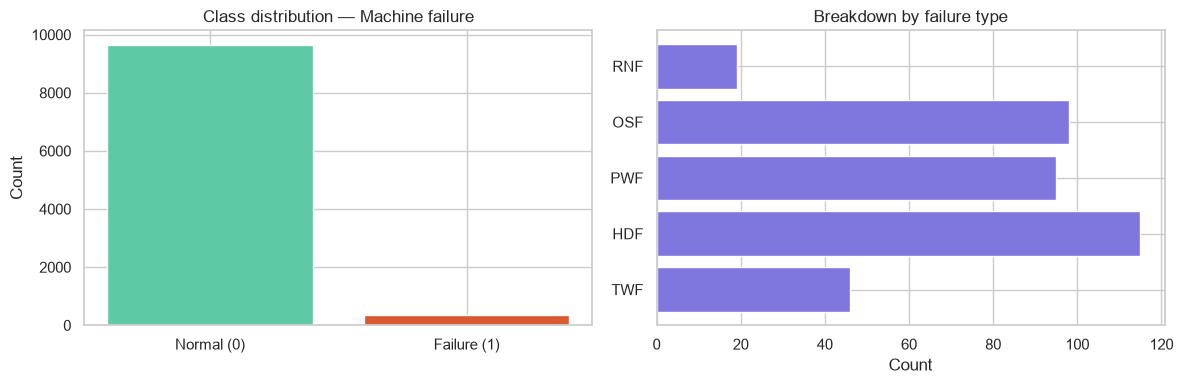

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall failure count
axes[0].bar(['Normal (0)', 'Failure (1)'],
            df['Machine failure'].value_counts().values,
            color=['#5DCAA5', '#D85A30'])
axes[0].set_title('Class distribution — Machine failure')
axes[0].set_ylabel('Count')

# Failure type breakdown
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
counts = [df[col].sum() for col in failure_types]
axes[1].barh(failure_types, counts, color='#7F77DD')
axes[1].set_title('Breakdown by failure type')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../docs/class_distribution.png', dpi=150)
plt.show()

In [3]:
print("=== Shape ===")
print(df.shape)

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Failure distribution ===")
failure_counts = df['Machine failure'].value_counts()
print(failure_counts)
print(f"\nFailure rate: {failure_counts[1]/len(df)*100:.2f}%")

=== Shape ===
(10000, 12)

=== Missing values ===
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

=== Data types ===
Type                    object
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
TWF                      int64
HDF                      int64
PWF                      int64
OSF                      int64
RNF                      int64
dtype: object

=== Failure distribution ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


In [4]:
dataset = fetch_ucirepo(id=601)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline